# All estimation for Employment gap ($u^*-u$)

In [1]:
# import
import pandas as pd
import statsmodels.api as sm

import numpyro
import numpyro.distributions as dist
from numpyro.contrib.control_flow import scan
from numpyro.infer import MCMC, NUTS
from numpyro.infer import Predictive
import numpy as np
from scipy.stats import norm, gaussian_kde
import arviz as az
import jax
import jax.numpy as jnp
from jax import random
import jax.random as random
from tqdm import tqdm
import re
from datetime import datetime
from IPython.display import Markdown, display, HTML
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
from matplotlib.lines import Line2D
import seaborn as sns
from statsmodels.tsa.filters.hp_filter import hpfilter

import warnings
warnings.simplefilter('ignore')

# --------------------------------------------------------
# global style
# --------------------------------------------------------
colors = ['black', 'blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "lines.linewidth": 1.5,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


/opt/homebrew/Caskroom/miniforge/base/envs/bayes-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tools for this notebook

In [2]:
def get_model_number(model_str):
    nums = re.findall(r'\d+', model_str)
    if nums:
        return int(nums[-1])
    else:
        return None
        
# for results
# SDDR
def sddr_alpha(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["alpha"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=alpha_mu, scale=alpha_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_kappa(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["kappa"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=kappa_mu, scale=kappa_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_theta(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["theta"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety
    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=theta_mu, scale=theta_sigma)
    return post_at0 / max(prior_at0, 1e-300)

def sddr_delta(idata):
    """BF_01 = posterior_density_at_0 / prior_density_at_0"""
    # posterior draws of kappa
    post = np.asarray(idata.posterior["delta"]).ravel()
    post = post[np.isfinite(post)]
    if post.size < 10:
        return np.nan  # safety

    # posterior density at 0 (KDE)
    kde = gaussian_kde(post)
    post_at0 = float(kde.evaluate([0.0])[0])
    # prior density at 0
    prior_at0 = norm.pdf(0.0, loc=delta_mu, scale=delta_sigma)
    return post_at0 / max(prior_at0, 1e-300)

    
# for plot
def plot_prior_posterior_grid(idatas, labels, params=("kappa","alpha","theta"),
                              figsize=(9,2.8), xlims=None):
    assert len(idatas) == len(labels)
    n_rows, n_cols = len(idatas), len(params)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize[0]*n_cols, figsize[1]*n_rows),
                             squeeze=False, sharey='col')

    priors = {"alpha": (alpha_mu, alpha_sigma),
              "kappa": (kappa_mu, kappa_sigma),
              "theta": (theta_mu, theta_sigma),
              "delta": (delta_mu, delta_sigma)}

    for i, (idata, label_row) in enumerate(zip(idatas, labels)):
        avail = set(idata.posterior.data_vars) if "posterior" in idata.__dict__ else set()
        for j, param in enumerate(params):
            ax = axes[i, j]
            if param in avail:
                az.plot_posterior(idata, var_names=[param], point_estimate=None,
                                  hdi_prob="hide", kind="kde", color="royalblue", ax=ax)
                if param in priors:
                    mu, sigma = priors[param]
                    if xlims and param in xlims:
                        xmin, xmax = xlims[param]
                    else:
                        xmin, xmax = mu - 5*sigma, mu + 5*sigma
                    x = np.linspace(xmin, xmax, 1000)
                    y = norm.pdf(x, mu, sigma)
                    ax.plot(x, y, "r--", lw=2, label="Prior")
            else:
                ax.set_xticks([]); ax.set_yticks([])

            if j == 0:
                ax.set_ylabel("Density", fontsize=11)
                # ax.set_title(label_row, fontsize=20, loc="left")
            ax.set_xlabel({"kappa": r"$\kappa$", "alpha": r"$\alpha$",
                           "theta": r"$\theta$", "delta": r"$\delta$"}.get(param, param), fontsize=16)
            if xlims and param in xlims: ax.set_xlim(xlims[param])

    legend_handles = [Line2D([0],[0], color="royalblue", lw=2, label="Posterior"),
                      Line2D([0],[0], color="red", lw=2, ls="--", label="Prior")]
    fig.legend(handles=legend_handles, fontsize=10, loc="lower center",
               ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    return fig

# Data

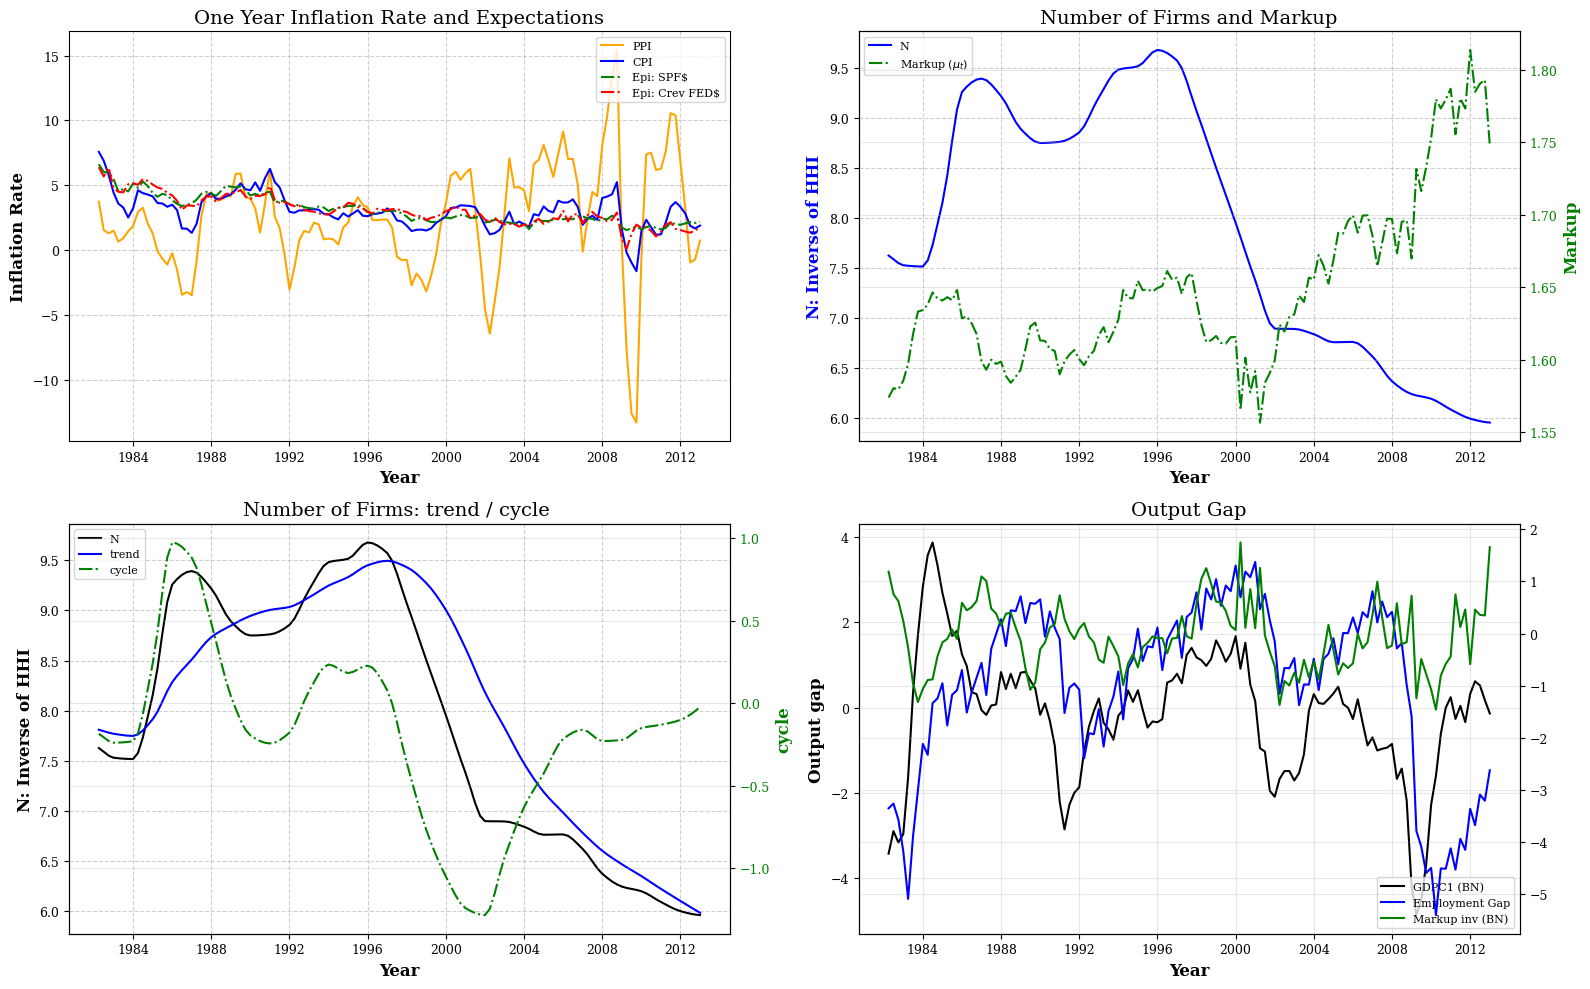

In [3]:
try:
    from scipy.interpolate import PchipInterpolator
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# ---- helper functions ----
def to_datetime(s, fmt=None):
    return pd.to_datetime(s, format=fmt) if fmt else pd.to_datetime(s)

def yoy_pct(series_q):
    # Exact YoY percent change: 100*(x/lag4 - 1)
    return 100 * (series_q / series_q.shift(4) - 1)

def log_yoy(series_q):
    # Log-difference YoY ×100
    return 100 * (np.log(series_q) - np.log(series_q).shift(4))

def resample_quarterly_mean(df, date_col, value_cols):
    x = df.copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()
    q = x.resample("Q").mean()  # quarterly mean
    q.index.freq = "Q"
    return q[value_cols]

def annual_to_quarterly_pchip(df, date_col, value_col):
    """
    Convert annual data to quarterly using PCHIP interpolation.
    Falls back to time/polynomial interpolation if scipy unavailable.
    """
    x = df[[date_col, value_col]].copy()
    x[date_col] = to_datetime(x[date_col])
    x = x.set_index(date_col).sort_index()

    a = x.asfreq("YS")
    q_index = pd.date_range(a.index.min(), a.index.max(), freq="Q")
    q = pd.DataFrame(index=q_index, data=np.nan, columns=[value_col])
    q.index.freq = "Q"
    merged = a.reindex(a.index.union(q.index)).sort_index()

    if _HAS_SCIPY:
        xi = merged.index.view("i8")
        mask = merged[value_col].notna().values
        xx = xi[mask].astype(float)
        yy = merged.loc[mask, value_col].astype(float).values
        if len(xx) >= 2:
            f = PchipInterpolator(xx, yy)
            merged[value_col] = pd.Series(f(xi.astype(float)), index=merged.index)
        else:
            merged[value_col] = merged[value_col].interpolate(method="time")
    else:
        try:
            merged[value_col] = merged[value_col].interpolate(method="time")
            merged[value_col] = merged[value_col].interpolate(method="polynomial", order=3)
        except Exception:
            merged[value_col] = merged[value_col].interpolate()

    return merged.reindex(q_index)

# ---- SPF (xlsx) ----
spf = pd.read_excel("../data/inflation/Inflation.xlsx")
q_month = (spf["QUARTER"] * 3)
spf["DATE"] = pd.to_datetime(
    spf["YEAR"].astype(str) + "-" + q_month.astype(str) + "-01"
) + pd.offsets.MonthEnd(0)
spf["Epi_spf_gdp"] = spf["INFPGDP1YR"]
spf["Epi_spf_cpi"] = spf["INFCPI1YR"]
tt_spf = spf[["DATE", "Epi_spf_gdp", "Epi_spf_cpi"]].set_index("DATE").sort_index()
tt_spf.index = tt_spf.index.to_period("Q").to_timestamp(how="end")
tt_spf.index.freq = "Q"

# ---- PPI -----------------------
ppi = pd.read_csv("../data/inflation/PPIACO.csv")
date_col = "DATE" if "DATE" in ppi.columns else ("observation_date" if "observation_date" in ppi.columns else None)
if date_col is None:
    raise ValueError("PPIACO.csv must have DATE or observation_date column.")
tt_ppi_m = ppi[[date_col, "PPIACO"]].copy()
tt_ppi_q = resample_quarterly_mean(ppi, date_col, ["PPIACO"])
tt_ppi_q["pi_ppi"] = yoy_pct(tt_ppi_q["PPIACO"])
tt_ppi_q = tt_ppi_q[["pi_ppi"]]


# ---- CPI headline (monthly → quarterly → YoY%) ----
cpi = pd.read_csv("../data/inflation/CPIAUCSL.csv")
date_col = "DATE" if "DATE" in cpi.columns else ("observation_date" if "observation_date" in cpi.columns else None)
if date_col is None:
    raise ValueError("CPIAUCSL.csv must have DATE or observation_date column.")
tt_cpi_q = resample_quarterly_mean(cpi, date_col, ["CPIAUCSL"])
tt_cpi_q["pi_cpi"] = yoy_pct(tt_cpi_q["CPIAUCSL"])
tt_cpi_q = tt_cpi_q[["pi_cpi"]]

# ---- Core CPI (log YoY) ----
core = pd.read_csv("../data/inflation/CPILFESL.csv")
date_col = "DATE" if "DATE" in core.columns else ("observation_date" if "observation_date" in core.columns else None)
if date_col is None:
    raise ValueError("CPILFESL.csv must have DATE or observation_date column.")
tt_core_m = core[[date_col, "CPILFESL"]].copy()
tt_core_m[date_col] = to_datetime(tt_core_m[date_col])
tt_core_q = tt_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_core_q.index.freq = "Q"
tt_core_q["pi_cpi_core"] = log_yoy(tt_core_q["CPILFESL"])
tt_core = tt_core_q[["pi_cpi_core"]]

# ---- PCE headline (log YoY) ----
pce = pd.read_csv("../data/inflation/PCEPI.csv")
date_col = "DATE" if "DATE" in pce.columns else ("observation_date" if "observation_date" in pce.columns else None)
tt_pce_m = pce[[date_col, "PCEPI"]].copy()
tt_pce_m[date_col] = to_datetime(tt_pce_m[date_col])
tt_pce_q = tt_pce_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_q.index.freq = "Q"
tt_pce_q["pi_pce"] = log_yoy(tt_pce_q["PCEPI"])
tt_pce = tt_pce_q[["pi_pce"]]

# ---- PCE core (log YoY) ----
pce_core = pd.read_csv("../data/inflation/PCEPILFE.csv")
date_col = "DATE" if "DATE" in pce_core.columns else ("observation_date" if "observation_date" in pce_core.columns else None)
tt_pce_core_m = pce_core[[date_col, "PCEPILFE"]].copy()
tt_pce_core_m[date_col] = to_datetime(tt_pce_core_m[date_col])
tt_pce_core_q = tt_pce_core_m.set_index(date_col).sort_index().resample("Q").mean()
tt_pce_core_q.index.freq = "Q"
tt_pce_core_q["pi_pce_core"] = log_yoy(tt_pce_core_q["PCEPILFE"])
tt_pce_core = tt_pce_core_q[["pi_pce_core"]]

# ---- N (annual → quarterly, cubic interp) ----
hhi = pd.read_csv("../data/competition/BN_N_26.csv")
hhi["N"] = hhi["original_series"]
hhi["year"] = pd.to_datetime(pd.to_datetime(hhi["date"]).dt.year.astype(str) + "-01-01")
tt_hhi_q = annual_to_quarterly_pchip(hhi.rename(columns={"year": "DATE"}), "DATE", "N")
# ---- N cycle and trend (annual → quarterly, cubic interp) ----
nb = pd.read_csv("../data/competition/BN_N_26.csv")
nb["N_BN_cycle"] = nb["cycle"]
nb["N_BN_trend"] = nb["trend"]
nb["DATE"] = pd.to_datetime(pd.to_datetime(nb["date"]).dt.year.astype(str) + "-01-01")
nb = nb[["DATE", "N_BN_cycle","N_BN_trend"]].dropna()
tt_nb_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_cycle")
tt_nb_trend_q = annual_to_quarterly_pchip(nb, "DATE", "N_BN_trend")

# ---- Markup levels ----
mk = pd.read_excel("../data/markup/nekarda_ramey_markups.xlsx")
mk["DATE"] = to_datetime(mk["qdate"])
mk["markup"] = mk["mu_bus"]
tt_mk = mk[["DATE", "markup"]].dropna().set_index("DATE").sort_index()
tt_mk.index = tt_mk.index.to_period("Q").to_timestamp(how="end")
tt_mk.index.freq = "Q"

# ---- BN inverse markup ----
mk_bn = pd.read_csv("../data/markup/BN_markup_inv.csv")
mk_bn["markup_BN_inv"] = mk_bn["cycle"]
mk_bn["DATE"] = to_datetime(mk_bn["date"])
tt_mk_bn = mk_bn[["DATE", "markup_BN_inv"]].dropna().set_index("DATE").sort_index()
tt_mk_bn.index = tt_mk_bn.index.to_period("Q").to_timestamp(how="end")
tt_mk_bn.index.freq = "Q"

# ---- Employment gap (NROU - UNRATENSA) ----
nairu = pd.read_csv("../data/unemp_gap/NROU.csv")
unemp = pd.read_csv("../data/unemp_gap/UNRATENSA.csv")

dc1 = "DATE" if "DATE" in nairu.columns else "observation_date"
dc2 = "DATE" if "DATE" in unemp.columns else "observation_date"

# Make sure both DATE columns are real datetimes (on both sides!)
n = nairu[[dc1, "NROU"]].rename(columns={dc1: "DATE"})
u = unemp[[dc2, "UNRATENSA"]].rename(columns={dc2: "DATE"})
n["DATE"] = pd.to_datetime(n["DATE"], errors="coerce")
u["DATE"] = pd.to_datetime(u["DATE"], errors="coerce")

tt_gap = (
    n.merge(u, on="DATE", how="outer")
     .set_index("DATE")
     .sort_index()
     .resample("Q").mean()
)
tt_gap.index.freq = "Q"
tt_gap["unemp_gap"] = tt_gap["NROU"] - tt_gap["UNRATENSA"]
tt_gap = tt_gap[["unemp_gap"]].dropna()

# ---- Output gap data (BN filter) ----
out = pd.read_csv("../data/output_gap/BN_filter_GDPC1_quaterly.csv")
out["output_BN"] = out["GDPC1_transformed_series"]
out["output_gap_BN"] = out["cycle"]
out["output"] = np.log(out["GDPC1_original_series"] * 0.01)
out["DATE"] = to_datetime(out["date"])
out["output_trend_BN"] = out["output_BN"] - out["output_gap_BN"]
tt_out = (
    out[["DATE", "output_BN", "output_gap_BN", "output_trend_BN", "output"]]
    .dropna()
    .set_index("DATE")
    .sort_index()
)
tt_out.index = tt_out.index.to_period("Q").to_timestamp(how="end")
tt_out.index.freq = "Q"

# ---- Oil prices (WTI deflated by CPI, log YoY) ----
oil = pd.read_csv("../data/others/WTISPLC_CPIAUCSL.csv")
dc = "DATE" if "DATE" in oil.columns else "observation_date"
tt_oil = oil[[dc, "WTISPLC_CPIAUCSL"]].copy()
tt_oil[dc] = to_datetime(tt_oil[dc])
tt_oil = tt_oil.set_index(dc).sort_index().resample("Q").mean()
tt_oil.index.freq = "Q"
tt_oil["log_oil"] = np.log(tt_oil["WTISPLC_CPIAUCSL"])
tt_oil["oil"] = tt_oil["log_oil"] - tt_oil["log_oil"].shift(4)
tt_oil = tt_oil[["oil"]]

# ---- Inflation expectations (monthly → quarterly mean ×100) ----
epi = pd.read_csv("../data/inflation/one_year_inflation_expectation.csv")
epi["DATE"] = to_datetime(epi["Date"], fmt="%Y-%m-%d")
epi.astype({"DATE": str}).set_index("DATE", inplace=True)
epi["Epi"] = epi[" Epi"] * 100
epi = epi[["DATE","Epi"]]
tt_epi_m = pd.DataFrame({"DATE": epi["DATE"], "Epi": epi["Epi"]}).set_index("DATE").sort_index()
tt_epi = tt_epi_m.resample("Q").mean()

def as_qe_midnight(df):
    """Force index to quarter-end at 00:00:00 (no nanoseconds)."""
    out = df.copy()
    # ensure datetime index
    out.index = pd.to_datetime(out.index)
    # convert to quarter periods then back to Timestamps at end-of-quarter
    out.index = pd.PeriodIndex(out.index, freq="Q").to_timestamp(how="end").normalize()
    out.index.name = "DATE"
    # freq is not needed; leave it unset to avoid surprises
    out.index.freq = None
    return out
dfs = [
    tt_cpi_q, tt_epi, tt_spf, tt_core, tt_out, tt_hhi_q, tt_nb_q,tt_nb_trend_q,
    tt_mk, tt_pce_core, tt_pce, tt_mk_bn, tt_gap, tt_oil, tt_ppi_q
]
dfs = [as_qe_midnight(d) for d in dfs] 
data = pd.concat(dfs, axis=1).sort_index()

data.index = data.index.to_period("Q").to_timestamp(how="end")
data.index.freq = "Q"

# ---- Add lagged variables ----
for col in ["pi_ppi","pi_cpi", "pi_cpi_core", "pi_pce", "pi_pce_core", "N_BN_trend", "N_BN_cycle"]:
    if col in data.columns:
        data[f"{col}_prev"] = data[col].shift(1)

    
data = data.loc["1982-01-01":"2012-12-31"]
data['DATE'] = pd.to_datetime(data.index)
# --- 2×2 graph ---
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Inflation and Expected Inflation ---
ax1= axs[0, 0]
ax1_left = ax1
ax1_left.plot(data["DATE"], data["pi_ppi"], label=r'PPI', color='orange')
ax1_left.plot(data["DATE"], data["pi_cpi"], label=r'CPI', color='blue')
ax1_left.plot(data["DATE"], data["Epi_spf_cpi"], label=r'Epi: SPF$', linestyle='-.', color='green')
ax1_left.plot(data["DATE"], data["Epi"], label=r'Epi: Crev FED$', linestyle='-.', color='red')
ax1_left.set_xlabel('Year', fontsize=12, weight='bold')
ax1_left.set_ylabel('Inflation Rate', fontsize=12, weight='bold', color = 'black')
ax1_left.grid(True, linestyle='--', alpha=0.6)
ax1_left.set_title('One Year Inflation Rate and Expectations', fontsize=14)
lines = ax1_left.get_lines()
labels = [line.get_label() for line in lines]
ax1_left.legend(lines, labels, loc='upper right', fontsize=8)

# --- 2. Number of Firms and Markup ---
ax2 = axs[0, 1]
ax2_left = ax2
ax2_right = ax2_left.twinx()
ax2_left.plot(data["DATE"], data["N"], label=r'N', color='blue')
ax2_right.plot(data["DATE"], data["markup"], label=r'Markup $(\mu_{t})$', linestyle='-.', color='green')
ax2_left.set_xlabel('Year', fontsize=12, weight='bold')
ax2_left.set_ylabel('N: Inverse of HHI', fontsize=12, weight='bold', color = 'blue')
ax2_right.set_ylabel('Markup', fontsize=12, weight='bold', color='green')
ax2_right.tick_params(axis='y', labelcolor='green')
ax2_left.grid(True, linestyle='--', alpha=0.6)
ax2_left.set_title('Number of Firms and Markup', fontsize=14)
lines = ax2_left.get_lines() + ax2_right.get_lines()
labels = [line.get_label() for line in lines]
ax2_left.legend(lines, labels, loc='upper left', fontsize=8)

# --- 3.  Number of Firms: trend / cycle ---
ax3 = axs[1, 0]
ax3_left = ax3
ax3_right = ax3_left.twinx()
ax3_left.plot(data["DATE"], data["N"], label='N', color='black')
ax3_left.plot(data["DATE"], data["N_BN_trend"], label='trend', color='blue')
ax3_right.plot(data["DATE"],data["N_BN_cycle"], label=r'cycle', linestyle='-.', color='green')
ax3_left.set_xlabel('Year', fontsize=12, weight='bold')
ax3_left.set_ylabel('N: Inverse of HHI', fontsize=12, weight='bold')
ax3_right.set_ylabel('cycle', fontsize=12, weight='bold', color='green')
ax3_right.tick_params(axis='y', labelcolor='green')
ax3_left.grid(True, linestyle='--', alpha=0.6)
ax3_left.set_title('Number of Firms: trend / cycle ', fontsize=14)
lines = ax3_left.get_lines() + ax3_right.get_lines()
labels = [line.get_label() for line in lines]
ax3_left.legend(lines, labels, loc='upper left', fontsize=8)

# --- 5. Output Gaps ------
ax5 = axs[1, 1]
ax5_left = ax5
ax5_right = ax5_left.twinx()
ax5_left.set_ylabel('Output gap', fontsize=12, weight='bold', color='black')
ax5_left.plot(data["DATE"], data["output_gap_BN"], label=r'GDPC1 (BN)', color='black')
ax5_right.plot(data["DATE"], data["unemp_gap"], label=r'Employment Gap', color='blue')
ax5_right.plot(data["DATE"], data["markup_BN_inv"], label=r'Markup inv (BN)', color='green')
ax5_left.set_title('Output Gap', fontsize=14)
ax5_left.set_xlabel('Year', fontsize=12, weight='bold')
lines = ax5_left.get_lines() + ax5_right.get_lines()
labels = [line.get_label() for line in lines]
ax5_left.legend(lines, labels, loc='lower right', fontsize=8)
# --- Layout ---
plt.tight_layout()
plt.show()


# for MCMC
pi = jnp.array(data['pi_cpi'],dtype=jnp.float64)
pi_prev = jnp.array(data['pi_cpi_prev'],dtype=jnp.float64)
pi_expect = jnp.array(data['Epi_spf_cpi'],dtype=jnp.float64)
N = jnp.array(data['N'],dtype=jnp.float64)
Nhat = jnp.array(data['N_BN_cycle'],dtype=jnp.float64)
Nbar = jnp.array(data['N_BN_trend'],dtype=jnp.float64)
Y = jnp.array(data['output'],dtype=jnp.float64)
x_unempgap = jnp.array(data['unemp_gap'],dtype=jnp.float64)

# Models

## CES
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa_{t}x_{t}+v_{t}$$

## HSA
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa_{t}x_{t}-\theta\hat{N}_{t}+v_{t}\\$$

# Estimation (baseline)

## OLS
$$\pi_{t}	=\alpha\pi_{t-1}+\beta \mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}+\theta\hat{N}_{t}+v_{t}$$

Restriction
$$\pi_{t}=\alpha\pi_{t-1}+ (1-\alpha) \mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}+\theta\hat{N}_{t}+v_{t}$$
or
$$\pi_{t}-\mathbb{E}_{t}\pi_{t+1}=\alpha(\pi_{t-1}-\mathbb{E}_{t}\pi_{t+1})+\kappa x_{t}+\theta\hat{N}_{t}+v_{t}$$


In [4]:
# ========= OLS =========
y = data["pi_cpi"]
X = pd.DataFrame({
    "pi_prev": data["pi_cpi_prev"],
    "Epi": data["Epi_spf_cpi"],
    "x2": data["unemp_gap"],
    "oil": data["oil"],
    "Nhat": data["N_BN_cycle_prev"]
})
df = pd.concat([y, X], axis=1).dropna()

periods = [("1982-01-01", "2012-12-31")]

# ========= 1) function =========
def run_models(df, periods):
    """
      U1: OLS (pi_prev, Epi, x2)
      U2: OLS (pi_prev, Epi, x2, Nhat)
      R1: Restricted OLS (pi_prev_minus_Epi, x2) on (pi_cpi - Epi)
      R2: Restricted OLS (pi_prev_minus_Epi, x2, Nhat) on (pi_cpi - Epi)
    """
    specs = [
        ("U1", "OLS:",               {"type":"unres", "x":["pi_prev","Epi","x2"]}),
        ("U2", "OLS:(Nhat)",             {"type":"unres", "x":["pi_prev","Epi","x2","Nhat"]}),
        ("R1", "Restricted OLS",      {"type":"res",   "x":["pi_prev_minus_Epi","x2"]}),
        ("R2", "Restricted OLS(Nhat)",       {"type":"res",   "x":["pi_prev_minus_Epi","x2","Nhat"]}),
    ]
    results = {}  # key=(period_label, model_id) -> fitted result
    implied = []  
    for (start, end) in periods:
        sub = df.loc[start:end].copy()
        period_label = f"{start}–{end}"
        sub["pi_prev_minus_Epi"] = sub["pi_prev"] - sub["Epi"]
        sub["Y_tilde"] = sub["pi_cpi"] - sub["Epi"]
        for model_id, model_name, spec in specs:
            if spec["type"] == "unres":
                Y = sub["pi_cpi"]
                Xr = sub[spec["x"]]
            else:
                Y = sub["Y_tilde"]
                Xr = sub[spec["x"]]

            res = sm.OLS(Y, Xr).fit()
            results[(period_label, model_id)] = {
                "name": model_name,
                "res": res
            }
            if spec["type"] == "res":
                b1 = res.params.get("pi_prev_minus_Epi", float("nan"))
                implied.append({
                    "Period": period_label,
                    "Model": model_id,
                    "ModelName": model_name,
                    "beta_pi_prev": b1,
                    "beta_Epi": 1 - b1
                })

    implied_df = pd.DataFrame(implied)
    return results, implied_df

def results_to_long_table_with_implied(results_dict, digits=6):
    rows = []
    for (period_label, model_id), pack in results_dict.items():
        res = pack["res"]
        model_name = pack.get("name", model_id)
        for var in res.params.index:
            rows.append({
                "Period": period_label,
                "Model": model_id,
                "ModelName": model_name,
                "Variable": var,
                "Coef": res.params[var],
                "StdErr": res.bse[var],
                "t": res.tvalues[var],
                "p": res.pvalues[var],
                "R2": res.rsquared,
                "N": int(res.nobs),
            })

        # Restricted 
        if "pi_prev_minus_Epi" in res.params.index:
            b1  = res.params["pi_prev_minus_Epi"]      # beta_pi_prev
            se1 = res.bse["pi_prev_minus_Epi"]
            t1  = res.tvalues["pi_prev_minus_Epi"]
            p1  = res.pvalues["pi_prev_minus_Epi"]
            rows = [r for r in rows if not (
                r["Period"] == period_label and r["Model"] == model_id and r["Variable"] == "pi_prev_minus_Epi"
            )]
            rows.append({
                "Period": period_label,
                "Model": model_id,
                "ModelName": model_name,
                "Variable": "pi_prev",
                "Coef": b1,
                "StdErr": se1,
                "t": t1,
                "p": p1,
                "R2": res.rsquared,
                "N": int(res.nobs),
            })            
            b2  = 1 - b1
            se2 = se1
            t2  = b2 / se2 if se2 != 0 else np.nan
            rows.append({
                "Period": period_label,
                "Model": model_id,
                "ModelName": model_name,
                "Variable": "Epi",
                "Coef": b2,
                "StdErr": se2,
                "t": t2,
                "p": np.nan,
                "R2": res.rsquared,
                "N": int(res.nobs),
            })

    out = pd.DataFrame(rows)
    out = out.sort_values(["Period", "Model", "Variable"]).reset_index(drop=True)
    return out.round(digits)

# ========= 3) wide =========
def long_to_wide(long_df, stat="Coef", digits=4):
    """
    stat in {"Coef","StdErr","t","p"} 
    rows: Variable
    cols: (Period, Model)
    """
    wide = long_df.pivot_table(
        index="Variable",
        columns=["Period","Model"],
        values=stat,
        aggfunc="first"
    )
    return wide.round(digits)


results_dict, implied_df = run_models(df, periods)
final_long = results_to_long_table_with_implied(results_dict).round(6)   
final_long = final_long[["ModelName","Variable", "Coef","StdErr","t","p","R2","N"]]
final_long

,ModelName,Variable,Coef,StdErr,t,p,R2,N
0,Restricted OLS,Epi,0.349480,0.056345,6.202544,NaN,0.546233,124
1,Restricted OLS,pi_prev,0.650520,0.056345,11.545366,0.000000,0.546233,124
2,Restricted OLS,x2,0.081501,0.030901,2.637442,0.009441,0.546233,124
3,Restricted OLS(Nhat),Epi,0.368277,0.057984,6.351418,NaN,0.552579,124
4,Restricted OLS(Nhat),Nhat,-0.147110,0.112297,-1.310007,0.192675,0.552579,124
5,Restricted OLS(Nhat),pi_prev,0.631723,0.057984,10.894867,0.000000,0.552579,124
6,Restricted OLS(Nhat),x2,0.084185,0.030879,2.726270,0.007357,0.552579,124
7,OLS:,Epi,0.339758,0.059844,5.677346,0.000000,0.961872,124
8,OLS:,pi_prev,0.650219,0.056523,11.503571,0.000000,0.961872,124
9,OLS:,x2,0.073134,0.035318,2.070726,0.040511,0.961872,124


## Bayesian Regression (mcmc)

In [5]:
# prior distribution
alpha_mu = 0.5
alpha_sigma = 0.5
kappa_mu = 0.1
kappa_sigma = 0.5
theta_mu = 0.1
theta_sigma = 0.5
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        # Sigma
        # non informative priors
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
    }
    return priors

from IPython.display import display, Math

def display_priors_latex():
    latex = rf"""
\begin{{aligned}}
\alpha &\sim \mathcal{{N}}({alpha_mu:.2f},\, {alpha_sigma:.2f}^2) \\
\kappa &\sim \mathcal{{N}}({kappa_mu:.2f},\, {kappa_sigma:.2f}^2) \\
\theta &\sim \mathcal{{N}}({theta_mu:.2f},\, {theta_sigma:.2f}^2) \\
\sigma_v &\sim \mathcal{{IG}}(0.001,\,0.001)
\end{{aligned}}
"""
    display(Math(latex))

display_priors_latex()

<IPython.core.display.Math object>

In [6]:
# CES
def model_ces(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    # Sigma
    sigma_v = numpyro.sample("sigma_v", priors["sigma_v"])
    # model
    pi_pred = alpha * pi_prev + (1-alpha) * pi_expect + kappa * x
    numpyro.sample(f"pi_obs", numpyro.distributions.Normal(pi_pred, sigma_v), obs=pi)
## =================================================================================
# HSA
def model_hsa(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha", priors["alpha"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    theta = numpyro.sample("theta", priors["theta"])
    # Sigma
    sigma_v = numpyro.sample("sigma_v", priors["sigma_v"])
    # model
    pi_pred = alpha * pi_prev + (1-alpha) * pi_expect + kappa * x - theta * Nhat
    numpyro.sample(f"pi_obs", numpyro.distributions.Normal(pi_pred, sigma_v), obs=pi)

In [7]:
# ---------------- MCMC run configuration ---------------
warmup = 1000
samples = 9000
chains = 2
# Target acceptance rate: lower values speed up sampling but may increase divergences.
TARGET_ACCEPT = 0.95
CHAIN_METHOD = "parallel"
PROGRESS_BAR = True
# for reproducibility
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()

model_dict = {
    "CES_emp": model_ces, 
    "HSA_emp": model_hsa,
}
dict_idata = {}
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: CES_emp


sample: 100%|██████████| 10000/10000 [00:01<00:00, 6554.71it/s, 7 steps of size 5.56e-01. acc. prob=0.96]


Divergence ratio for CES_emp: 0.0000%
Running NKPC model: HSA_emp


sample: 100%|██████████| 10000/10000 [00:01<00:00, 5724.41it/s, 7 steps of size 4.87e-01. acc. prob=0.96]


Divergence ratio for HSA_emp: 0.0000%

=== All models finished ===



model,alpha,theta,kappa
CES_emp,"0.6490 [0.5340, 0.7540]",nan,"0.0820 [0.0190, 0.1420]"
HSA_emp,"0.6320 [0.5210, 0.7450]","0.1370 [-0.0710, 0.3500]","0.0830 [0.0220, 0.1440]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
CES_emp,0.0,0.548512,nan,nan
HSA_emp,0.0,0.538458,2.146,nan


[plot_prior_posterior_grid] error: name 'delta_mu' is not defined


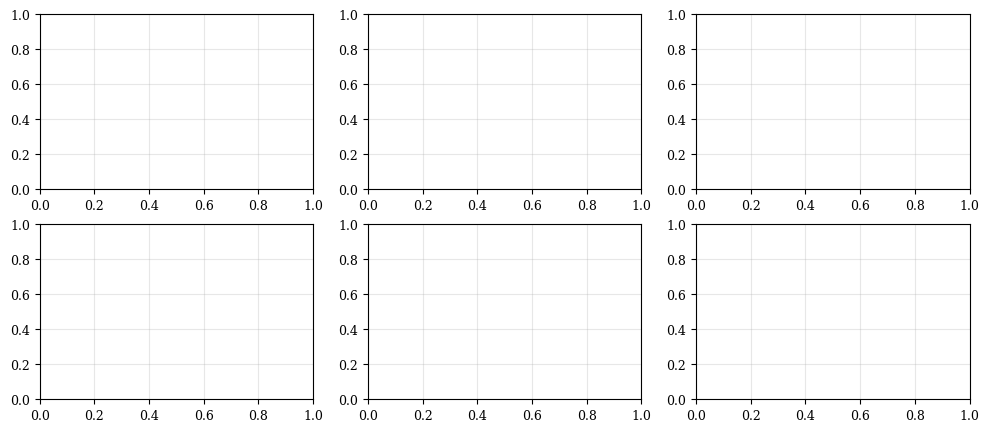

In [8]:
# results
models_to_show ={
    "CES_emp", "HSA_emp"
}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "kappa"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "kappa", "theta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 1), "alpha": (0, 1.0), "theta": (-0.4, 1)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")

## HSA, Joint decomposition
$$\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
N_{t}	=\hat{N_{t}}+\bar{N_{t}}\\
\hat{N_{t}}	=\rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N_{t}}	=n+\bar{N}_{t-1}+\epsilon_{t}$$

In [9]:
# prior distribution
alpha_mu = 0.5
alpha_sigma = 0.5
kappa_mu = 0.1
kappa_sigma = 0.5
theta_mu = 0.1
theta_sigma = 0.5
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "n"          : dist.Normal(0, 1), 
        # Sigma
        # non informative priors
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_u"    : dist.InverseGamma(0.001, 0.001), 
        "sigma_eps"    : dist.InverseGamma(0.001, 0.001), 
    }
    return priors


def display_priors_latex():
    latex = rf"""
\begin{{aligned}}
\alpha &\sim \mathcal{{N}}({alpha_mu:.2f},\, {alpha_sigma:.2f}^2) \\
\kappa &\sim \mathcal{{N}}({kappa_mu:.2f},\, {kappa_sigma:.2f}^2) \\
\theta &\sim \mathcal{{N}}({theta_mu:.2f},\, {theta_sigma:.2f}^2) \\
n &\sim \mathcal{{N}}(0, 1^2) \\
\sigma_v &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_u &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_\epsilon &\sim \mathcal{{IG}}(0.001,\,0.001)
\end{{aligned}}
"""
    display(Math(latex))

display_priors_latex()

<IPython.core.display.Math object>

In [10]:
## =================================================================================
# HSA joint decomposition
def model_hsa_decomp(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    kappa = numpyro.sample("kappa", priors["kappa"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        t = carry[3]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa * x[t] - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t , Nhat_t, Nhat_prev_1 , t], None
    scan(transition, [bar_N_0, hat_N_1, hat_N_0, t], timesteps)

In [11]:
# Target acceptance rate: lower values speed up sampling but may increase divergences.
TARGET_ACCEPT = 0.95
CHAIN_METHOD = "parallel"
PROGRESS_BAR = True
# for reproducibility
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()

model_dict = { 
    "HSA_emp_decomp": model_hsa_decomp,
}
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: HSA_emp_decomp


sample: 100%|██████████| 10000/10000 [00:50<00:00, 199.69it/s, 511 steps of size 2.12e-02. acc. prob=0.97]


Divergence ratio for HSA_emp_decomp: 0.0000%

=== All models finished ===



model,alpha,theta,kappa,rho_1,rho_2,n
HSA_emp_decomp,"0.6310 [0.5190, 0.7490]","0.2530 [-0.2130, 0.6990]","0.0900 [0.0280, 0.1540]","1.7860 [1.7000, 1.8750]","-0.8850 [-0.9700, -0.7980]","-0.0140 [-0.0250, -0.0040]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_emp_decomp,0.0,0.319478,1.196,nan


[plot_prior_posterior_grid] error: name 'delta_mu' is not defined


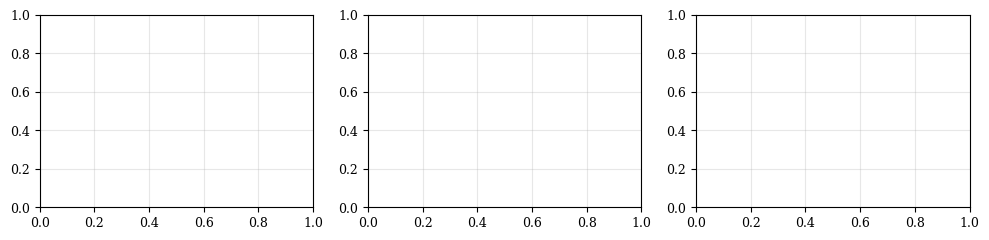

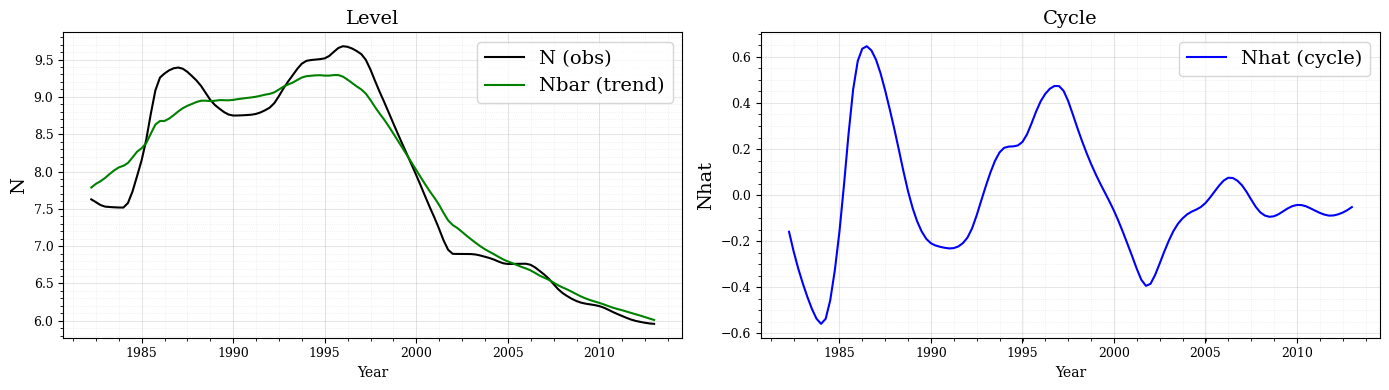

In [12]:
# results
models_to_show ={
    "HSA_emp_decomp"
}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "kappa", "rho_1", "rho_2", "n"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "kappa", "theta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 1), "alpha": (0, 1.0), "theta": (-0.4, 1)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


display(HTML("<h3>Decomposed N for Each Model</h3>"))

for model_name, idata in dict_items_fill.items():
    if "Nbar_t" in idata.posterior:

        # ---- Samples ----
        Nhat_samples = idata.posterior["Nhat_t"].values
        Nhat_samples = Nhat_samples.reshape(-1, Nhat_samples.shape[-1])
        Nhat_mean = np.mean(Nhat_samples, axis=0)

        Nbar_samples = idata.posterior["Nbar_t"].values
        Nbar_samples = Nbar_samples.reshape(-1, Nbar_samples.shape[-1])
        Nbar_mean = np.mean(Nbar_samples, axis=0)

        # ---- Figure: two panels ----
        fig, (ax1, ax2) = plt.subplots(
            ncols=2, figsize=(14, 4), sharex=True
        )

        # =========================
        # Left panel: Level
        # =========================
        ax1.plot(data["DATE"], data["N"], label="N (obs)", color="black")
        ax1.plot(data["DATE"], Nbar_mean, label="Nbar (trend)", color="green")
        ax1.set_title("Level", fontsize=14)
        ax1.set_ylabel("N", fontsize=14)
        ax1.legend(loc="upper right", fontsize=14)

        # =========================
        # Right panel: Cycle
        # =========================
        ax2.plot(data["DATE"], Nhat_mean, label="Nhat (cycle)", color="blue")
        ax2.set_title("Cycle", fontsize=14)
        ax2.set_ylabel("Nhat", fontsize=14)
        ax2.legend(loc="upper right", fontsize=14)

        # ---- X-axis formatting (shared) ----
        for ax in (ax1, ax2):
            ax.set_xlabel("Year")
            ax.xaxis.set_major_locator(mdates.YearLocator(5))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            ax.xaxis.set_minor_locator(mdates.YearLocator(1))
            ax.minorticks_on()
            ax.grid(which="major", linestyle="-", linewidth=0.75)
            ax.grid(which="minor", linestyle=":", linewidth=0.5)
        plt.tight_layout()
        plt.show()


## HSA, time-variant kappa
$$
\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
$$
$$
\kappa_{t}	=\kappa_{t-1}+\delta \Delta \bar{N}_{t}
$$

In [13]:
# prior distribution
alpha_mu = 0.5
alpha_sigma = 0.5
kappa_mu = 0.1
kappa_sigma = 0.5
theta_mu = 0.1
theta_sigma = 0.5
delta_mu = 0.1
delta_sigma = 0.5
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "kappa0"      : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "delta"      : dist.Normal(delta_mu, delta_sigma), 
        # Sigma
        # non informative priors
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
    }
    return priors


def display_priors_latex():
    latex = rf"""
\begin{{aligned}}
\alpha &\sim \mathcal{{N}}({alpha_mu:.2f},\, {alpha_sigma:.2f}^2) \\
\kappa &\sim \mathcal{{N}}({kappa_mu:.2f},\, {kappa_sigma:.2f}^2) \\
\theta &\sim \mathcal{{N}}({theta_mu:.2f},\, {theta_sigma:.2f}^2) \\
\delta &\sim \mathcal{{N}}({delta_mu:.2f},\, {delta_sigma:.2f}^2) \\
n &\sim \mathcal{{N}}(0, 1^2) \\
\sigma_v &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\end{{aligned}}
"""
    display(Math(latex))

display_priors_latex()

<IPython.core.display.Math object>

In [14]:
## =================================================================================
# HSA time-varying kappa
def model_hsa_tv(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    kappa0 = numpyro.sample("kappa0", priors["kappa0"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", dist.Normal(0, 1))
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        kappa_prev = carry[0]
        t = carry[1]        
        # kappa      
        dNbar = jnp.concatenate([jnp.array([0.0]), jnp.diff(Nbar)])
        kappa_t = kappa_prev + delta * dNbar[t]
        numpyro.deterministic("kappa_t", kappa_t)         
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x[t] - theta * Nhat[t]
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [kappa_t , t], None
    scan(transition, [kappa0, t], timesteps)

In [15]:
# Target acceptance rate: lower values speed up sampling but may increase divergences.
TARGET_ACCEPT = 0.95
CHAIN_METHOD = "parallel"
PROGRESS_BAR = True
# for reproducibility
rng_key = jax.random.PRNGKey(0)
rng_keys = jax.random.split(rng_key, chains)
numpyro.enable_x64()

model_dict = { 
    "HSA_tv_emp": model_hsa_tv,
}
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")


=== Run models ===
Running NKPC model: HSA_tv_emp


sample: 100%|██████████| 10000/10000 [00:02<00:00, 4431.94it/s, 15 steps of size 3.57e-01. acc. prob=0.97]


Divergence ratio for HSA_tv_emp: 0.0000%

=== All models finished ===



model,alpha,theta,delta
HSA_tv_emp,"0.6380 [0.5240, 0.7500]","0.0830 [-0.1350, 0.2970]","0.0630 [0.0030, 0.1260]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_tv_emp,0.0,nan,3.524,2.071


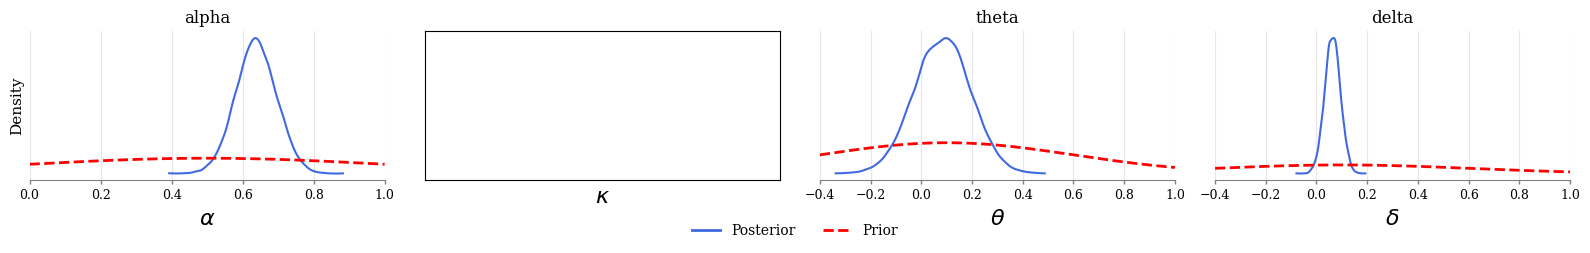

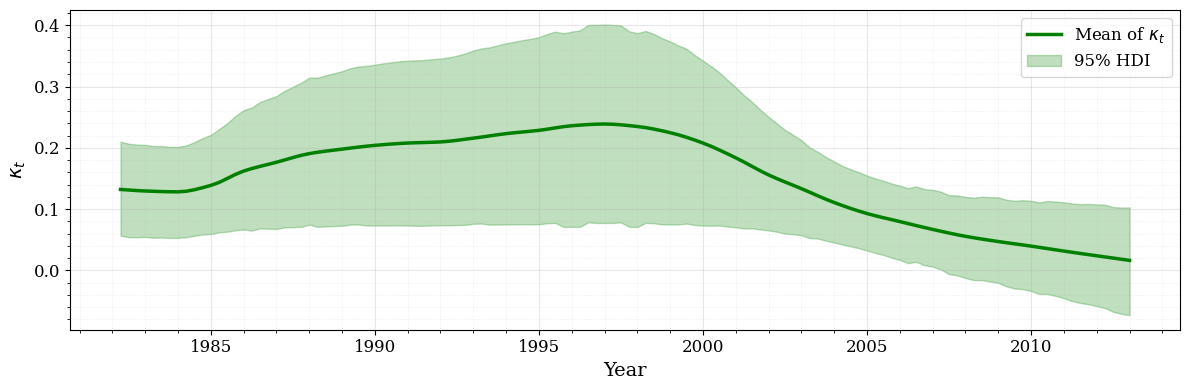

In [16]:
# results
models_to_show ={"HSA_tv_emp"}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "delta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "kappa", "theta", "delta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 1), "alpha": (0, 1.0), "theta": (-0.4, 1), "delta": (-0.4, 1)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


# ===== Plot kappa_t for each model with 95% HDI =====
display(HTML("<h3>Latent Variable kappa_t (95% HDI) for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
        # Extract kappa_t samples from posterior
        if "kappa_t" in idata.posterior:
            kappa_samples = idata.posterior["kappa_t"].values
            # Flatten chain and draw dimensions: (chain, draw, time) -> (samples, time)
            kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
            
            # Calculate mean and 95% HDI using ArviZ
            kappa_mean = np.mean(kappa_samples, axis=0)
            kappa_hdi = az.hdi(kappa_samples, hdi_prob=0.95)
            kappa_lower = kappa_hdi[:, 0]
            kappa_upper = kappa_hdi[:, 1]
            
            # Moving average
            window = 5
            kappa_ma = pd.Series(kappa_mean).rolling(window=window, center=True).mean()
            
        # Plot
        plt.figure(figsize=(12, 4))

        plt.plot(
            data["DATE"], kappa_mean,
            label=r"Mean of $\kappa_t$",
            color="green",
            linewidth=2.5
        )

        plt.fill_between(
            data["DATE"], kappa_lower, kappa_upper,
            color="green",
            alpha=0.25,
            label="95% HDI"
        )

        # ---- Labels (bigger) ----
        plt.xlabel("Year", fontsize=14)
        plt.ylabel(r"$\kappa_t$", fontsize=14)

        # ---- Legend (bigger) ----
        plt.legend(fontsize=12)

        # ---- Ticks (bigger) ----
        plt.tick_params(axis="both", which="major", labelsize=12)
        plt.tick_params(axis="both", which="minor", labelsize=10)

        # ---- Grid ----
        plt.minorticks_on()
        plt.grid(which="major", linestyle="-", linewidth=0.75)
        plt.grid(which="minor", linestyle=":", linewidth=0.5)

        # ---- X-axis formatting ----
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))

        plt.tight_layout()
        plt.show()

## HSA, time-variant kappa, joint decomposition
$$
\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E}_{t}\pi_{t+1}+\kappa x_{t}-\theta\hat{N}_{t}+v_{t}\\
N_{t}	=\hat{N_{t}}+\bar{N_{t}}\\
\hat{N_{t}}	=\rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N_{t}}	=n+\bar{N}_{t-1}+\epsilon_{t}\\
\kappa_{t}	=\kappa_{t-1}+\delta \Delta \bar{N}_{t}
$$

In [17]:
## =================================================================================
# HSA time-varying kappa and joint decomposition of N
def model_tv_decomp_hsa(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", priors["delta"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    kappa0 = numpyro.sample("kappa0", priors["kappa"])   # kappa init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        kappa_prev = carry[3]
        t = carry[4]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        Nhat_t = numpyro.deterministic("Nhat_t", Nhat_obs) 
        # kappa
        kappa_t = kappa_prev + delta *(Nbar_t - Nbar_prev)
        numpyro.deterministic("kappa_t", kappa_t)    
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * x[t] - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t, Nhat_t, Nhat_prev_1, kappa_t, t], None
    scan(transition, [bar_N_0, hat_N_0, hat_N_1, kappa0, t], timesteps)




In [18]:
# prior distribution
alpha_mu = 0.5
alpha_sigma = 0.5
kappa_mu = 0.1
kappa_sigma = 0.5
theta_mu = 0.1
theta_sigma = 0.5
delta_mu = 0.1
delta_sigma = 0.5
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "delta"      : dist.Normal(delta_mu, delta_sigma), 
        "n"          : dist.Normal(0, 1), 
        # Sigma
        # non informative priors
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_u"    : dist.InverseGamma(0.001, 0.001), 
        "sigma_eps"    : dist.InverseGamma(0.001, 0.001), 
    }
    return priors


def display_priors_latex():
    latex = rf"""
\begin{{aligned}}
\alpha &\sim \mathcal{{N}}({alpha_mu:.2f},\, {alpha_sigma:.2f}^2) \\
\kappa &\sim \mathcal{{N}}({kappa_mu:.2f},\, {kappa_sigma:.2f}^2) \\
\theta &\sim \mathcal{{N}}({theta_mu:.2f},\, {theta_sigma:.2f}^2) \\
\delta &\sim \mathcal{{N}}({delta_mu:.2f},\, {delta_sigma:.2f}^2) \\
n &\sim \mathcal{{N}}(0, 1^2) \\
\sigma_v &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_u &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_\epsilon &\sim \mathcal{{IG}}(0.001,\,0.001)
\end{{aligned}}
"""
    display(Math(latex))

display_priors_latex()

<IPython.core.display.Math object>

In [19]:
model_dict = {
    "HSA_tv_decomp_emp": model_tv_decomp_hsa,
}
# 1) model
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")

=== Run models ===
Running NKPC model: HSA_tv_decomp_emp


sample: 100%|██████████| 10000/10000 [00:43<00:00, 229.12it/s, 127 steps of size 2.69e-02. acc. prob=0.95]


Divergence ratio for HSA_tv_decomp_emp: 0.0000%

=== All models finished ===



model,alpha,theta,delta
HSA_tv_decomp_emp,"0.6270 [0.5130, 0.7360]","0.2550 [-0.1580, 0.6720]","0.0710 [0.0140, 0.1280]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_tv_decomp_emp,0.0,nan,1.111,1.042


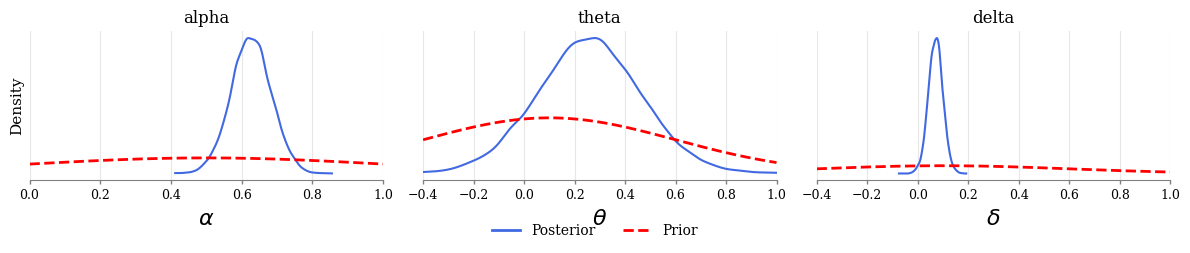

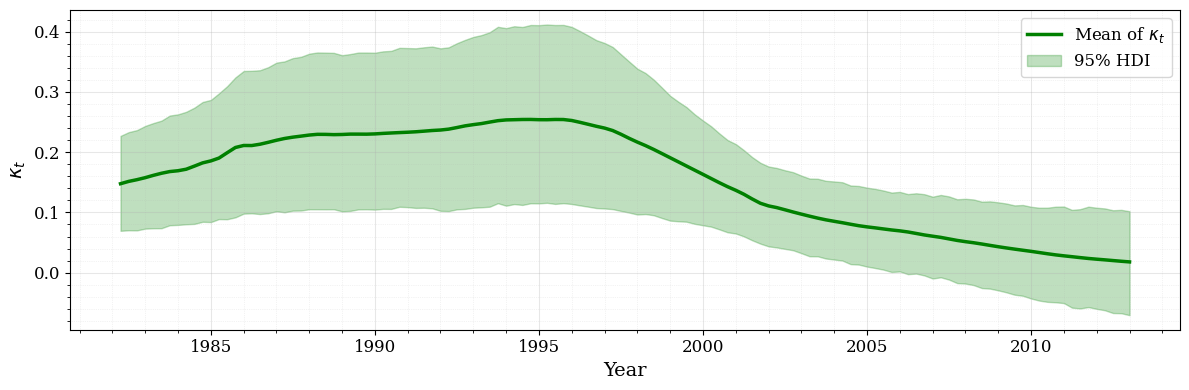

In [20]:
# results
models_to_show ={"HSA_tv_decomp_emp"}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "delta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "theta", "delta")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 1), "alpha": (0, 1.0), "theta": (-0.4, 1), "delta": (-0.4, 1)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


# ===== Plot kappa_t for each model with 95% HDI =====
display(HTML("<h3>Latent Variable kappa_t (95% HDI) for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
        # Extract kappa_t samples from posterior
        if "kappa_t" in idata.posterior:
            kappa_samples = idata.posterior["kappa_t"].values
            # Flatten chain and draw dimensions: (chain, draw, time) -> (samples, time)
            kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
            
            # Calculate mean and 95% HDI using ArviZ
            kappa_mean = np.mean(kappa_samples, axis=0)
            kappa_hdi = az.hdi(kappa_samples, hdi_prob=0.95)
            kappa_lower = kappa_hdi[:, 0]
            kappa_upper = kappa_hdi[:, 1]
            
            # Moving average
            window = 5
            kappa_ma = pd.Series(kappa_mean).rolling(window=window, center=True).mean()
            
        # Plot
        plt.figure(figsize=(12, 4))

        plt.plot(
            data["DATE"], kappa_mean,
            label=r"Mean of $\kappa_t$",
            color="green",
            linewidth=2.5
        )

        plt.fill_between(
            data["DATE"], kappa_lower, kappa_upper,
            color="green",
            alpha=0.25,
            label="95% HDI"
        )

        # ---- Labels (bigger) ----
        plt.xlabel("Year", fontsize=14)
        plt.ylabel(r"$\kappa_t$", fontsize=14)

        # ---- Legend (bigger) ----
        plt.legend(fontsize=12)

        # ---- Ticks (bigger) ----
        plt.tick_params(axis="both", which="major", labelsize=12)
        plt.tick_params(axis="both", which="minor", labelsize=10)

        # ---- Grid ----
        plt.minorticks_on()
        plt.grid(which="major", linestyle="-", linewidth=0.75)
        plt.grid(which="minor", linestyle=":", linewidth=0.5)

        # ---- X-axis formatting ----
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))

        plt.tight_layout()
        plt.show()

## HSA, time-variant kappa, joint decomposition
$$
\pi_{t}	=\alpha\pi_{t-1}+(1-\alpha)\mathbb{E^*}_{t}\pi_{t+1}+\kappa_t x_{t}-\theta\hat{N}_{t}+v_{t}\\
N_{t}	=\hat{N_{t}}+\bar{N_{t}}\\
\hat{N_{t}}	=\rho_{1}\hat{N}_{t-1}+\rho_{2}\hat{N}_{t-2}+u_{t}\\
\bar{N_{t}}	=n+\bar{N}_{t-1}+\epsilon_{t}\\
\kappa_{t}	=\kappa_{t-1}+\delta \Delta \bar{N}_{t} + e_t\\
x_t= \gamma_{1}x_{t-1}+\gamma_{2}\hat{N}_{t-1}+\gamma_{3}\pi_{t-1}+\mu_{t}\\
$$

<IPython.core.display.Math object>

=== Run models ===
Running NKPC model: HSA_tv_decomp_emp_temp


sample: 100%|██████████| 20000/20000 [14:31<00:00, 22.94it/s, 340 steps of size 1.92e-02. acc. prob=0.93] 


Divergence ratio for HSA_tv_decomp_emp_temp: 51.2316%

=== All models finished ===



model,alpha,theta,delta
HSA_tv_decomp_emp_temp,"0.6270 [0.5100, 0.7390]","0.2780 [-0.1900, 0.7570]","0.0720 [0.0160, 0.1300]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_tv_decomp_emp_temp,0.0,nan,2.026,1.649


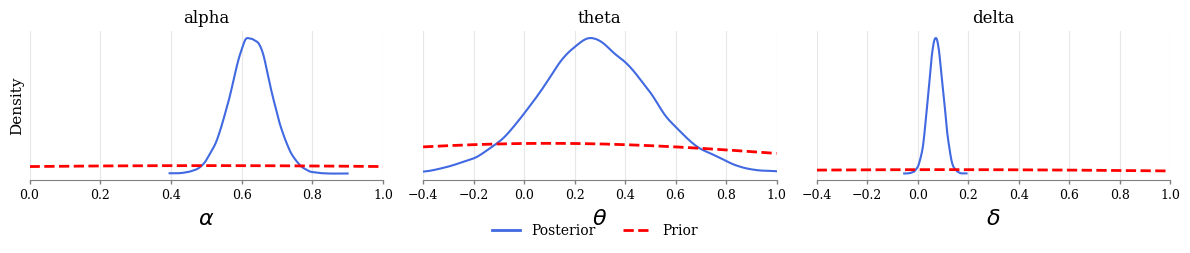

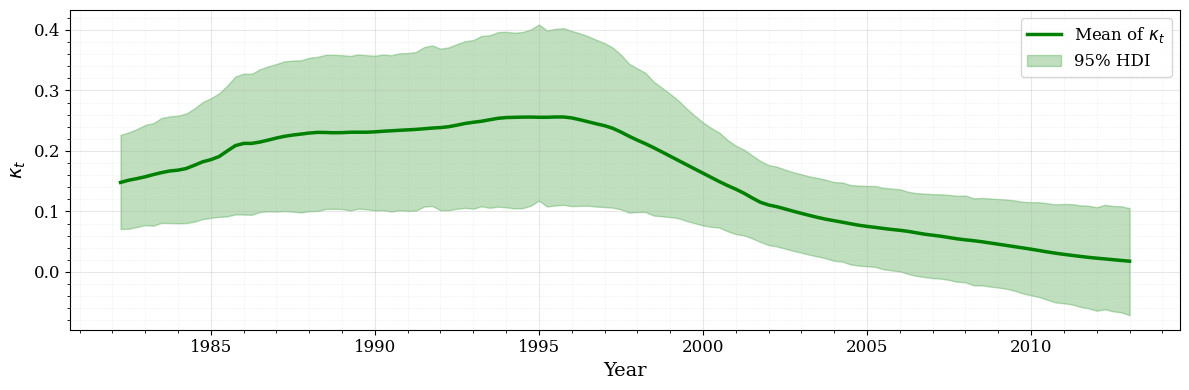

In [ ]:
# ---------------- MCMC run configuration ---------------
warmup = 1000
samples = 19000
chains = 2
## =================================================================================
# HSA time-varying kappa and joint decomposition of N
def model_tv_decomp_hsa_temp(pi, pi_prev, pi_expect, x, N, Nbar, Nhat, l):
    priors = set_prior_distributions()
    # NKPC params
    alpha = numpyro.sample("alpha",priors["alpha"])
    theta = numpyro.sample("theta", priors["theta"])
    delta = numpyro.sample("delta", priors["delta"])
    # gammas
    gamma_1 = numpyro.sample("gamma_1", priors["gamma"])
    gamma_2 = numpyro.sample("gamma_2", priors["gamma"])
    gamma_3 = numpyro.sample("gamma_3", priors["gamma"])
    # State equation (N) params
    r = numpyro.sample("r", dist.Uniform(-1,1))      
    p = numpyro.sample("p", dist.Uniform(0.1, 0.9))  
    rho_1 = 2 * r * jnp.cos(jnp.pi * p)
    rho_2 = -r ** 2
    numpyro.deterministic("rho_1", rho_1) # Nhat AR1 coeff
    numpyro.deterministic("rho_2", rho_2) # Nhat AR2 coeff
    n = numpyro.sample("n", priors["n"])
    # Sigma
    sigma_v  = numpyro.sample("sigma_v", priors["sigma_v"])      
    sigma_u  = numpyro.sample("sigma_u", priors["sigma_u"])      
    sigma_eps = numpyro.sample("sigma_eps", priors["sigma_eps"]) 
    sigma_e = numpyro.sample("sigma_e", priors["sigma_e"]) 
    sigma_mu = numpyro.sample("sigma_mu", priors["sigma_mu"]) 
    # initial 
    bar_N_0  = numpyro.sample("bar_N_0", dist.Normal(N[0], 1))   # Nbar init
    hat_N_0  = numpyro.sample("hat_N_0", dist.Normal(0, .05))    # Nhat init
    hat_N_1  = numpyro.sample("hat_N_1", dist.Normal(0, .05))    # Nhat init
    kappa0 = numpyro.sample("kappa0", priors["kappa"])   # kappa init
    # state space model
    timesteps = jnp.arange(l)
    t = 0
    def transition(carry, _):        
        Nbar_prev = carry[0]
        Nhat_prev_1 = carry[1]
        Nhat_prev_2 = carry[2]
        kappa_prev = carry[3]
        t = carry[4]
        # trend 
        Nbar_t = numpyro.sample("Nbar_t", dist.Normal(n + Nbar_prev, sigma_eps))
        # N (Nbar + Nhat = observed N)
        Nhat_obs = N[t] - Nbar_t
        # cycle
        Nhat_t = numpyro.sample("Nhat_pred", dist.Normal(rho_1 * Nhat_prev_1 + rho_2 * Nhat_prev_2, sigma_u), obs=Nhat_obs)
        # kappa
        kappa_t = numpyro.deterministic("kappa_t", kappa_prev + delta * (Nbar_t - Nbar_prev))
        # cycle
        xstar_t = numpyro.sample("xstar_t", dist.Normal(gamma_1 * x[t-1] + gamma_2 * Nhat_prev_1 + gamma_3 * pi_prev[t], sigma_mu), obs=x[t])
        # pi
        pi_pred = alpha * pi_prev[t] + (1-alpha) * pi_expect[t] + kappa_t * xstar_t - theta * Nhat_t
        numpyro.sample(f"pi_obs", dist.Normal(pi_pred, sigma_v), obs=pi[t])
        t = t + 1
        return [Nbar_t, Nhat_t, Nhat_prev_1, kappa_t, t], None
    scan(transition, [bar_N_0, hat_N_0, hat_N_1, kappa0, t], timesteps)


# prior distribution
alpha_mu = 0.5
alpha_sigma = 1
kappa_mu = 0.1
kappa_sigma = 1
theta_mu = 0.1
theta_sigma = 1
delta_mu = 0.1
delta_sigma = 1
gamma_mu = 0
gamma_sigma = 1
def set_prior_distributions():
    priors = {
        # NKPC params
        "alpha"      : dist.Normal(alpha_mu, alpha_sigma),
        "kappa"      : dist.Normal(kappa_mu, kappa_sigma),
        "theta"      : dist.Normal(theta_mu, theta_sigma), 
        "delta"      : dist.Normal(delta_mu, delta_sigma), 
        "gamma"      : dist.Normal(gamma_mu, gamma_sigma), 
        "n"          : dist.Normal(0, 1), 
        # Sigma
        # non informative priors
        "sigma_v"    : dist.InverseGamma(0.001, 0.001),  
        "sigma_u"    : dist.InverseGamma(0.001, 0.001), 
        "sigma_eps"    : dist.InverseGamma(0.001, 0.001), 
        "sigma_e"    : dist.InverseGamma(0.001, 0.001), 
        "sigma_mu"    : dist.InverseGamma(0.001, 0.001), 
    }
    return priors


def display_priors_latex():
    latex = rf"""
\begin{{aligned}}
\alpha &\sim \mathcal{{N}}({alpha_mu:.2f},\, {alpha_sigma:.2f}^2) \\
\kappa &\sim \mathcal{{N}}({kappa_mu:.2f},\, {kappa_sigma:.2f}^2) \\
\theta &\sim \mathcal{{N}}({theta_mu:.2f},\, {theta_sigma:.2f}^2) \\
\delta &\sim \mathcal{{N}}({delta_mu:.2f},\, {delta_sigma:.2f}^2) \\
n &\sim \mathcal{{N}}(0, 1^2) \\
\sigma_v &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_u &\sim \mathcal{{IG}}(0.001,\,0.001) \\
\sigma_\epsilon &\sim \mathcal{{IG}}(0.001,\,0.001)
\end{{aligned}}
"""
    display(Math(latex))

display_priors_latex()


model_dict = {
    "HSA_tv_decomp_emp_temp": model_tv_decomp_hsa_temp,
}
# 1) model
print("=== Run models ===")
for model_name, m in model_dict.items():
    print(f"Running NKPC model: {model_name}")
    kernel = NUTS(m, target_accept_prob=TARGET_ACCEPT)
    mcmc = MCMC(kernel, num_warmup=warmup, num_samples=samples, num_chains=chains, chain_method=CHAIN_METHOD, progress_bar=PROGRESS_BAR)
    mcmc.run(rng_keys, pi=pi, pi_prev=pi_prev, pi_expect=pi_expect, x=x_unempgap, N=N, Nhat=Nhat, Nbar=Nbar, l=len(pi))
    idata = az.from_numpyro(mcmc)
    dict_idata[model_name] = idata
    # Divergence diagnostics
    diverging = idata.sample_stats["diverging"].values
    ratio_div = float(np.mean(diverging))
    print(f"Divergence ratio for {model_name}: {ratio_div:.4%}")
print("\n=== All models finished ===\n")

model,alpha,theta,delta
HSA_tv_decomp_emp_temp,"0.6270 [0.5100, 0.7390]","0.2780 [-0.1900, 0.7570]","0.0720 [0.0160, 0.1300]"


model,SDDR_BF01_alpha,SDDR_BF01_kappa,SDDR_BF01_theta,SDDR_BF01_delta
HSA_tv_decomp_emp_temp,0.0,nan,2.026,1.649


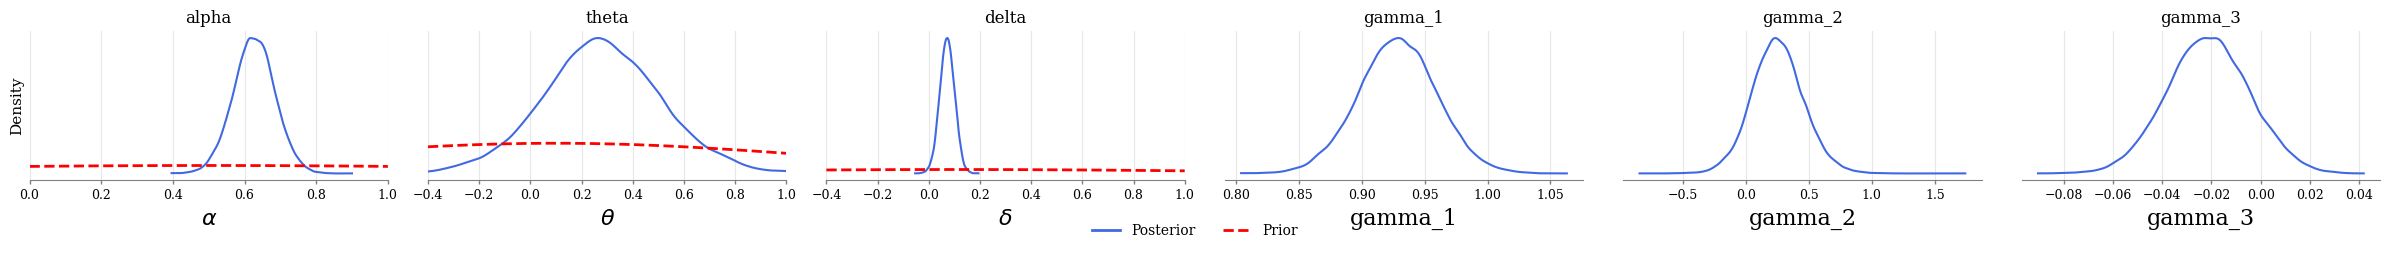

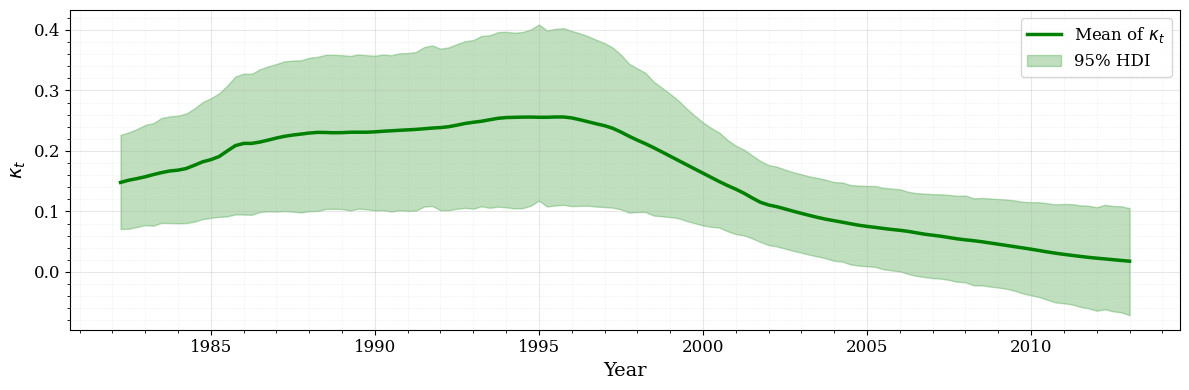

In [23]:

# results
models_to_show ={"HSA_tv_decomp_emp_temp"}
# dict_idata subset
dict_items_fill = {k: v for k, v in dict_idata.items() if k in models_to_show}
show_hdi = True
target_params = ["alpha", "theta", "delta"]
# ------- Summary table -------
summ_list = []
for model_name, idata in dict_items_fill.items():
    present = set(idata.posterior.data_vars)
    selected = list(present.intersection(target_params))
    if len(selected) == 0:
        continue
    # ArviZ summary
    s = az.summary(idata, var_names=selected, hdi_prob=0.95)
    s["param"] = s.index
    s["model"] = model_name
    s = s.reset_index(drop=True)
    s = s[["model", "param", "mean", "hdi_2.5%", "hdi_97.5%"]]
    summ_list.append(s)
summary_long = pd.concat(summ_list, ignore_index=True)

# ---- HDI on/off ----
if show_hdi:
    summary_long["value"] = summary_long.apply(
        lambda r: f"{r['mean']:.4f} [{r['hdi_2.5%']:.4f}, {r['hdi_97.5%']:.4f}]",
        axis=1
    )
else:
    summary_long["value"] = summary_long["mean"].map(lambda x: f"{x:.4f}")

# pivot
summary_wide = (
    summary_long.pivot_table(
        index="model",
        columns="param",
        values="value",
        aggfunc="first",
    )
    .reindex(columns=target_params)
    .reset_index()
    .rename_axis(None, axis=1)
)

display(HTML("<h3>Summary</h3>"))
display(summary_wide.style.hide(axis="index"))

# SDDR（kappa / theta）table
sddr_rows = []
for model_name, idata in dict_items_fill.items():
    try:
        bf01_alpha = sddr_alpha(idata)
    except Exception:
        bf01_alpha = np.nan
    try:
        bf01_kappa = sddr_kappa(idata)
    except Exception:
        bf01_kappa = np.nan
    try:
        bf01_theta = sddr_theta(idata)
    except Exception:
        bf01_theta = np.nan
    try:
        bf01_delta = sddr_delta(idata)
    except Exception:
        bf01_delta = np.nan
    sddr_rows.append({
        "model": model_name,
        "SDDR_BF01_alpha": bf01_alpha,
        "SDDR_BF01_kappa": bf01_kappa,
        "SDDR_BF01_theta": bf01_theta,
        "SDDR_BF01_delta": bf01_delta,
    })

df_sddr = pd.DataFrame(sddr_rows)
df_sddr["SDDR_BF01_alpha"] = df_sddr["SDDR_BF01_alpha"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_theta"] = df_sddr["SDDR_BF01_theta"].map(lambda v: f"{v:.4}")
df_sddr["SDDR_BF01_delta"] = df_sddr["SDDR_BF01_delta"].map(lambda v: f"{v:.4}")


display(HTML("<h3>SDDR: kappa: Bayes Factor (BF01)</h3>"))
display(df_sddr.style.hide(axis="index"))

display(HTML("<h3>prior vs posterior </h3>"))
# 6) prior vs posterior 
params = ("alpha", "theta", "delta","gamma_1", "gamma_2", "gamma_3")
try:
    idatas = [idata for _, idata in dict_items_fill.items()]
    labels  = [name for name, _ in dict_items_fill.items()]
    fig = plot_prior_posterior_grid(
            figsize=(4,2.5),
            idatas=idatas,
            labels=labels,
            params=params,
            xlims={"kappa": (-0.15, 1), "alpha": (0, 1.0), "theta": (-0.4, 1), "delta": (-0.4, 1)})
    plt.show()
except Exception as e:
    print(f"[plot_prior_posterior_grid] error: {e}")


# ===== Plot kappa_t for each model with 95% HDI =====
display(HTML("<h3>Latent Variable kappa_t (95% HDI) for Each Model</h3>"))
for model_name, idata in dict_items_fill.items():
        # Extract kappa_t samples from posterior
        if "kappa_t" in idata.posterior:
            kappa_samples = idata.posterior["kappa_t"].values
            # Flatten chain and draw dimensions: (chain, draw, time) -> (samples, time)
            kappa_samples = kappa_samples.reshape(-1, kappa_samples.shape[-1])
            
            # Calculate mean and 95% HDI using ArviZ
            kappa_mean = np.mean(kappa_samples, axis=0)
            kappa_hdi = az.hdi(kappa_samples, hdi_prob=0.95)
            kappa_lower = kappa_hdi[:, 0]
            kappa_upper = kappa_hdi[:, 1]
            
            # Moving average
            window = 5
            kappa_ma = pd.Series(kappa_mean).rolling(window=window, center=True).mean()
            
        # Plot
        plt.figure(figsize=(12, 4))

        plt.plot(
            data["DATE"], kappa_mean,
            label=r"Mean of $\kappa_t$",
            color="green",
            linewidth=2.5
        )

        plt.fill_between(
            data["DATE"], kappa_lower, kappa_upper,
            color="green",
            alpha=0.25,
            label="95% HDI"
        )

        # ---- Labels (bigger) ----
        plt.xlabel("Year", fontsize=14)
        plt.ylabel(r"$\kappa_t$", fontsize=14)

        # ---- Legend (bigger) ----
        plt.legend(fontsize=12)

        # ---- Ticks (bigger) ----
        plt.tick_params(axis="both", which="major", labelsize=12)
        plt.tick_params(axis="both", which="minor", labelsize=10)

        # ---- Grid ----
        plt.minorticks_on()
        plt.grid(which="major", linestyle="-", linewidth=0.75)
        plt.grid(which="minor", linestyle=":", linewidth=0.5)

        # ---- X-axis formatting ----
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.YearLocator(5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator(1))

        plt.tight_layout()
        plt.show()